In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

url = 'https://raw.githubusercontent.com/yogeshveus/CVDmodel/refs/heads/main/Nhanes_cvd_raw.csv'
df = pd.read_csv(url)
url_pf = 'https://raw.githubusercontent.com/yogeshveus/CVDmodel/refs/heads/main/processed/'
X_train_before_smote = pd.read_csv(url_pf + 'X_train_before_smote.csv')
X_train_after_smote = pd.read_csv(url_pf + 'X_train_after_smote.csv')
y_train_before_smote = pd.read_csv(url_pf + 'y_train_before_smote.csv')
y_train_after_smote = pd.read_csv(url_pf + 'y_train_after_smote.csv')
X_test = pd.read_csv(url_pf + 'X_test.csv')
y_test = pd.read_csv(url_pf + 'y_test.csv')

In [ ]:
print(df.shape)
print(df.columns.tolist())
df.head()

## Quantum-Classical Neural Network

In [3]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 80.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.3 MB/s eta 0:00:00


In [4]:
%pip install pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Function
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torchsummary import summary

import pylatexenc
import qiskit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import circuit_drawer
import qiskit.visualization
from torch.utils.data import TensorDataset, DataLoader

from qiskit import QuantumCircuit as QiskitQuantumCircuit

In [6]:
use_cuda = torch.cuda.is_available()

print('CUDA available:', use_cuda)

if use_cuda:
    device = torch.device('cuda')
    print('Training on GPU...')
else:
    device = torch.device('cpu')
    print('Training on CPU...')

CUDA available: False
Training on CPU...


In [7]:
def to_numpy(x):
    if hasattr(x, "values"):
        return x.values
    return np.asarray(x)


X_train_np = to_numpy(X_train_after_smote).astype(np.float32)
y_train_np = to_numpy(y_train_after_smote).astype(np.float32)

X_test_np = to_numpy(X_test).astype(np.float32)
y_test_np = to_numpy(y_test).astype(np.float32)


print("\nDataset shapes")
print("-------------------------")
print("X_train:", X_train_np.shape)
print("y_train:", y_train_np.shape)
print("X_test :", X_test_np.shape)
print("y_test :", y_test_np.shape)



Dataset shapes
-------------------------
X_train: (17382, 29)
y_train: (17382, 1)
X_test : (2501, 29)
y_test : (2501, 1)


In [ ]:
X_train_tensor = torch.tensor(
    X_train_np,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_np,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_np,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_np,
    dtype=torch.float32
)


train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
class QuantumFunction(
    torch.autograd.Function
):


    @staticmethod
    def forward(
        ctx,
        inputs,
        ry_weights,
        rz_weights,
        quantum_circuit
    ):

        inputs_np = (
            inputs.detach()
            .cpu()
            .numpy()
        )

        ry_np = (
            ry_weights.detach()
            .cpu()
            .numpy()
        )

        rz_np = (
            rz_weights.detach()
            .cpu()
            .numpy()
        )


        batch_size = inputs_np.shape[0]

        n_qubits = inputs_np.shape[1]


        outputs = []


        for b in range(batch_size):

            expectation = (
                quantum_circuit.run(
                    inputs_np[b],
                    ry_np,
                    rz_np
                )
            )

            outputs.append(
                expectation
            )


        outputs = np.asarray(
            outputs,
            dtype=np.float32
        )


        result = torch.tensor(
            outputs,
            dtype=inputs.dtype,
            device=inputs.device
        )


        # Save tensors for backward
        ctx.save_for_backward(
            inputs,
            ry_weights,
            rz_weights
        )

        ctx.quantum_circuit = quantum_circuit


        return result


    @staticmethod
    def backward(
        ctx,
        grad_output
    ):

        inputs, ry_weights, rz_weights = (
            ctx.saved_tensors
        )

        quantum_circuit = (
            ctx.quantum_circuit
        )


        inputs_np = (
            inputs.detach()
            .cpu()
            .numpy()
        )

        ry_np = (
            ry_weights.detach()
            .cpu()
            .numpy()
        )

        rz_np = (
            rz_weights.detach()
            .cpu()
            .numpy()
        )

        grad_output_np = (
            grad_output.detach()
            .cpu()
            .numpy()
        )


        batch_size = inputs_np.shape[0]

        n_qubits = inputs_np.shape[1]


        # ----------------------------------------------------
        # Parameter-shift rule
        #
        # d f / d theta =
        #     [f(theta + pi/2) - f(theta - pi/2)] / 2
        # ----------------------------------------------------

        shift = np.pi / 2


        # Gradient with respect to classical inputs
        grad_inputs = np.zeros_like(
            inputs_np,
            dtype=np.float32
        )


        # Gradient with respect to quantum RY weights
        grad_ry = np.zeros_like(
            ry_np,
            dtype=np.float32
        )


        # Gradient with respect to quantum RZ weights
        grad_rz = np.zeros_like(
            rz_np,
            dtype=np.float32
        )

        for b in range(batch_size):

            for p in range(n_qubits):

                inputs_plus = (
                    inputs_np[b].copy()
                )

                inputs_minus = (
                    inputs_np[b].copy()
                )


                inputs_plus[p] += shift

                inputs_minus[p] -= shift


                output_plus = (
                    quantum_circuit.run(
                        inputs_plus,
                        ry_np,
                        rz_np
                    )
                )

                output_minus = (
                    quantum_circuit.run(
                        inputs_minus,
                        ry_np,
                        rz_np
                    )
                )


                derivative = (
                    output_plus -
                    output_minus
                ) / 2.0


                # Chain rule:
                #
                # scalar loss gradient =
                # sum(output_gradient * output_derivative)

                grad_inputs[b, p] = np.sum(
                    grad_output_np[b] *
                    derivative
                )


        for p in range(n_qubits):

            ry_plus = ry_np.copy()

            ry_minus = ry_np.copy()

            ry_plus[p] += shift

            ry_minus[p] -= shift


            for b in range(batch_size):

                output_plus = (
                    quantum_circuit.run(
                        inputs_np[b],
                        ry_plus,
                        rz_np
                    )
                )

                output_minus = (
                    quantum_circuit.run(
                        inputs_np[b],
                        ry_minus,
                        rz_np
                    )
                )


                derivative = (
                    output_plus -
                    output_minus
                ) / 2.0


                grad_ry[p] += np.sum(
                    grad_output_np[b] *
                    derivative
                )


        for p in range(n_qubits):

            rz_plus = rz_np.copy()

            rz_minus = rz_np.copy()

            rz_plus[p] += shift

            rz_minus[p] -= shift


            for b in range(batch_size):

                output_plus = (
                    quantum_circuit.run(
                        inputs_np[b],
                        ry_np,
                        rz_plus
                    )
                )

                output_minus = (
                    quantum_circuit.run(
                        inputs_np[b],
                        ry_np,
                        rz_minus
                    )
                )


                derivative = (
                    output_plus -
                    output_minus
                ) / 2.0


                grad_rz[p] += np.sum(
                    grad_output_np[b] *
                    derivative
                )


        grad_inputs = torch.tensor(
            grad_inputs,
            dtype=inputs.dtype,
            device=inputs.device
        )

        grad_ry = torch.tensor(
            grad_ry,
            dtype=ry_weights.dtype,
            device=ry_weights.device
        )

        grad_rz = torch.tensor(
            grad_rz,
            dtype=rz_weights.dtype,
            device=rz_weights.device
        )


        return (
            grad_inputs,
            grad_ry,
            grad_rz,
            None
        )


In [ ]:
class QuantumCircuit:

    def __init__(
        self,
        n_qubits=4,
        backend=None,
        shots=128
    ):

        self.n_qubits = n_qubits
        self.backend = backend
        self.shots = shots
        self.input_params = [
            qiskit.circuit.Parameter(f"x_{i}")
            for i in range(n_qubits)
        ]

        self.ry_params = [
            qiskit.circuit.Parameter(f"ry_{i}")
            for i in range(n_qubits)
        ]

        self.rz_params = [
            qiskit.circuit.Parameter(f"rz_{i}")
            for i in range(n_qubits)
        ]

        self.circuit = qiskit.QuantumCircuit(
            n_qubits
        )

        # Input encoding
        for i in range(n_qubits):

            self.circuit.ry(
                self.input_params[i],
                i
            )

        # Trainable rotations
        for i in range(n_qubits):

            self.circuit.ry(
                self.ry_params[i],
                i
            )

            self.circuit.rz(
                self.rz_params[i],
                i
            )

        for i in range(n_qubits - 1):

            self.circuit.cx(
                i,
                i + 1
            )

        # Close the ring
        self.circuit.cx(
            n_qubits - 1,
            0
        )

        # Measurement
        self.circuit.measure_all()


    def run(
        self,
        inputs,
        ry_weights,
        rz_weights
    ):

        inputs = np.asarray(
            inputs
        ).reshape(-1)

        ry_weights = np.asarray(
            ry_weights
        ).reshape(-1)

        rz_weights = np.asarray(
            rz_weights
        ).reshape(-1)

        parameter_map = {}

        for i in range(self.n_qubits):

            parameter_map[
                self.input_params[i]
            ] = float(inputs[i])

            parameter_map[
                self.ry_params[i]
            ] = float(ry_weights[i])

            parameter_map[
                self.rz_params[i]
            ] = float(rz_weights[i])

        bound_circuit = (
            self.circuit.assign_parameters(
                parameter_map
            )
        )

        job = self.backend.run(
            bound_circuit,
            shots=self.shots
        )

        counts = (
            job.result()
            .get_counts()
        )

        expectations = np.zeros(
            self.n_qubits,
            dtype=np.float32
        )


        for bitstring, count in counts.items():

            probability = (
                count / self.shots
            )

            # Qiskit bit ordering
            bits = bitstring[::-1]

            for q in range(self.n_qubits):

                if bits[q] == "0":

                    expectations[q] += (
                        probability
                    )

                else:

                    expectations[q] -= (
                        probability
                    )


        return expectations

In [ ]:
class QuantumLayer(nn.Module):

    def __init__(
        self,
        n_qubits=4,
        backend=None,
        shots=128
    ):

        super().__init__()


        self.n_qubits = n_qubits


        self.quantum_circuit = QuantumCircuit(
            n_qubits=n_qubits,
            backend=backend,
            shots=shots
        )


        self.ry_weights = nn.Parameter(
            torch.randn(
                n_qubits
            ) * 0.1
        )


        self.rz_weights = nn.Parameter(
            torch.randn(
                n_qubits
            ) * 0.1
        )


    def forward(self, x):

        return QuantumFunction.apply(
            x,
            self.ry_weights,
            self.rz_weights,
            self.quantum_circuit
        )



In [ ]:
class QuantumCVDNet(nn.Module):

    def __init__(
        self,
        n_features,
        n_qubits=4,
        backend=None,
        shots=128
    ):

        super().__init__()


        self.n_qubits = n_qubits


        self.fc1 = nn.Linear(
            n_features,
            32
        )


        self.bn1 = nn.BatchNorm1d(
            32
        )


        self.dropout = nn.Dropout(
            0.20
        )

        self.fc2 = nn.Linear(
            32,
            n_qubits
        )

        self.quantum = QuantumLayer(
            n_qubits=n_qubits,
            backend=backend,
            shots=shots
        )

        self.fc3 = nn.Linear(
            n_qubits,
            1
        )


    def forward(self, x):

        # Classical feature extraction

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = torch.tanh(x)
        x = x * np.pi


        # Quantum circuit
        x = self.quantum(x)

        # Classical classifier
        x = self.fc3(x)

        return x

In [15]:
backend = AerSimulator()

In [ ]:
n_features = X_train_np.shape[1]

N_QUBITS = 4

SHOTS = 128


model = QuantumCVDNet(
    n_features=n_features,
    n_qubits=N_QUBITS,
    backend=backend,
    shots=SHOTS
).to(device)

print("\nModel")
print(model)




Model
QuantumCVDNet(
  (fc1): Linear(in_features=29, out_features=32, bias=True)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
  (quantum): QuantumLayer()
  (fc3): Linear(in_features=4, out_features=1, bias=True)
)


In [17]:
loss_func = nn.BCEWithLogitsLoss()

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


In [ ]:
from tqdm.auto import tqdm

EPOCHS = 40

loss_list = []

model.train()

for epoch in range(EPOCHS):

    total_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        leave=True
    )

    for batch_idx, (data, target) in enumerate(progress_bar):

        data = data.to(device)
        target = target.to(device).float().reshape(-1, 1)

        optimizer.zero_grad()
        logits = model(data)
        loss = loss_func(
            logits,
            target
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        total_loss += loss.item()
        avg_loss = total_loss / (batch_idx + 1)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{avg_loss:.4f}"
        )

    epoch_loss = total_loss / len(train_loader)
    loss_list.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"completed | "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 1/40:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 1/40 completed | Loss: 0.6450


Epoch 2/40:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 2/40 completed | Loss: 0.5473


Epoch 3/40:   0%|          | 0/272 [00:00<?, ?it/s]

...

Epoch 38/40 completed | Loss: 0.4456


Epoch 39/40:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 39/40 completed | Loss: 0.4452


Epoch 40/40:   0%|          | 0/272 [00:00<?, ?it/s]

Epoch 40/40 completed | Loss: 0.4466


In [22]:
MODEL_PATH = "/kaggle/working/quantum_cvdnet_new.pth"

torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved successfully to: {MODEL_PATH}")


Model saved successfully to: /kaggle/working/quantum_cvdnet_new.pth


In [23]:
CHECKPOINT_PATH = "/kaggle/working/quantum_cvdnet_checkpoint_new.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "n_features": n_features,
    "n_qubits": N_QUBITS,
    "shots": SHOTS,
    "epochs": EPOCHS,
    "loss_list": loss_list
}, CHECKPOINT_PATH)

print(f"Checkpoint saved to: {CHECKPOINT_PATH}")


Checkpoint saved to: /kaggle/working/quantum_cvdnet_checkpoint_new.pth


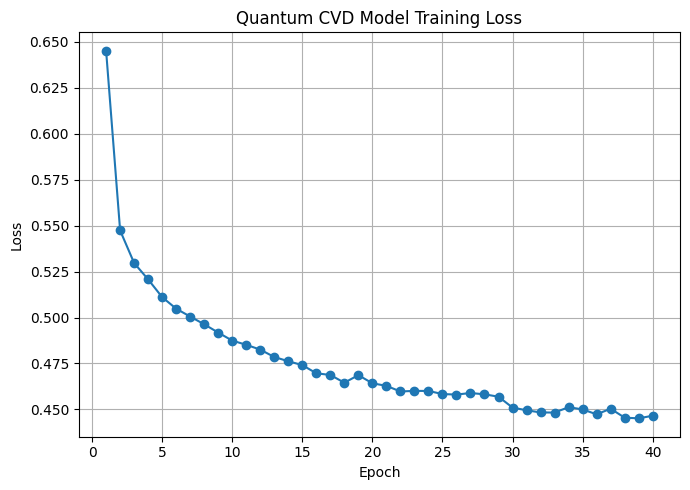

In [24]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(
        1,
        len(loss_list) + 1
    ),
    loss_list,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Quantum CVD Model Training Loss"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
def evaluate_model_quantum(
    model,
    test_loader,
    model_name="Quantum CVD Model",
    threshold=0.5
):

    model.eval()


    y_true = []

    y_prob = []


    with torch.no_grad():

        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)
            logits = model(data)
            probability = torch.sigmoid(
                logits
            )


            y_prob.extend(
                probability
                .detach()
                .cpu()
                .numpy()
                .ravel()
            )


            y_true.extend(
                target
                .detach()
                .cpu()
                .numpy()
                .ravel()
            )


    y_true = np.asarray(
        y_true
    ).astype(int)


    y_prob = np.asarray(
        y_prob
    )
    y_pred = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    if cm.shape == (2, 2):

        tn, fp, fn, tp = cm.ravel()

    else:

        tn = fp = fn = tp = 0


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    metrics = {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1 Score":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_prob
            )
    }

    print("\n")
    print("=" * 50)
    print(model_name)
    print("=" * 50)


    for metric, value in metrics.items():

        print(
            f"{metric:<20}: "
            f"{value:.4f}"
        )


    print("\nConfusion Matrix")

    print(cm)


    print("\nPrediction distribution")

    print(
        "Predicted 0:",
        np.sum(y_pred == 0)
    )

    print(
        "Predicted 1:",
        np.sum(y_pred == 1)
    )


    plt.figure(
        figsize=(6, 5)
    )


    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Predicted 0",
            "Predicted 1"
        ],
        yticklabels=[
            "Actual 0",
            "Actual 1"
        ]
    )


    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.title(
        f"{model_name}\nThreshold = {threshold}"
    )


    plt.tight_layout()

    plt.show()


    return (
        metrics,
        y_true,
        y_prob,
        y_pred
    )


In [26]:
import seaborn as sns



4-Qubit Quantum CVD Model
Accuracy            : 0.7541
Precision           : 0.2941
Recall              : 0.6250
Specificity         : 0.7736
F1 Score            : 0.4000
ROC-AUC             : 0.7806

Confusion Matrix
[[1681  492]
 [ 123  205]]

Prediction distribution
Predicted 0: 1804
Predicted 1: 697


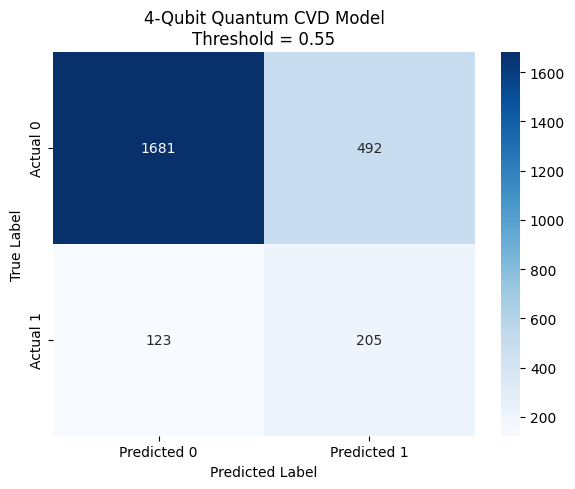



THRESHOLD ANALYSIS
Threshold=0.10 | Accuracy=0.498 | Precision=0.196 | Recall=0.915 | F1=0.323
Threshold=0.15 | Accuracy=0.537 | Precision=0.207 | Recall=0.896 | F1=0.337
Threshold=0.20 | Accuracy=0.566 | Precision=0.216 | Recall=0.878 | F1=0.347
Threshold=0.25 | Accuracy=0.599 | Precision=0.227 | Recall=0.854 | F1=0.358
Threshold=0.30 | Accuracy=0.634 | Precision=0.241 | Recall=0.832 | F1=0.373
Threshold=0.35 | Accuracy=0.657 | Precision=0.248 | Recall=0.796 | F1=0.378
Threshold=0.40 | Accuracy=0.686 | Precision=0.262 | Recall=0.765 | F1=0.390
Threshold=0.45 | Accuracy=0.712 | Precision=0.275 | Recall=0.732 | F1=0.400
Threshold=0.50 | Accuracy=0.736 | Precision=0.287 | Recall=0.686 | F1=0.405
Threshold=0.55 | Accuracy=0.754 | Precision=0.294 | Recall=0.625 | F1=0.400
Threshold=0.60 | Accuracy=0.777 | Precision=0.316 | Recall=0.598 | F1=0.413
Threshold=0.65 | Accuracy=0.796 | Precision=0.330 | Recall=0.540 | F1=0.410
Threshold=0.70 | Accuracy=0.813 | Precision=0.340 | Recall=0.454 | 

In [ ]:
quantum_metrics, y_true, y_prob, y_pred = (
    evaluate_model_quantum(
        model,
        test_loader,
        model_name="4-Qubit Quantum CVD Model",
        threshold=0.55
    )
)

'''
print("\n")
print("=" * 70)
print("THRESHOLD ANALYSIS")
print("=" * 70)


for threshold in np.arange(
    0.10,
    0.91,
    0.05
):

    predictions = (
        y_prob >= threshold
    ).astype(int)


    acc = accuracy_score(
        y_true,
        predictions
    )


    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )


    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )


    print(
        f"Threshold={threshold:.2f} | "
        f"Accuracy={acc:.3f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )
'''